# The complete oil and gas value chain: governed decisions with NeqSim support

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/automation/extend-complete-value-chain-20260806/notebooks/valuechain/complete_oil_and_gas_value_chain_with_neqsim.ipynb)

This is the **orientation notebook** for the NeqSim-Colab collection. It connects licence access,
subsurface characterization, reservoirs, wells, subsea and SURF, topsides, export, markets,
operations, emissions, and late-life decisions through one governed handoff chain.

After completing the notebook, you should be able to:

- identify the primary discipline owner and the NeqSim support role at each lifecycle stage;
- build and validate a reusable NeqSim separation, compression, and cooling workflow;
- translate one governed fluid basis into process, hydraulic, product-quality, emissions, and value
  evidence;
- screen operating scenarios and uncertainty without confusing a screen with specialist design;
- explain why laboratory PVT interpretation, EOS tuning, and reservoir PVT approval remain owned by
  specialist PVT and reservoir-model workflows.

NeqSim is deliberately **supporting, not primary, for PVT** in this lifecycle map. It can reproduce
and quality-check governed fluid descriptions, but measured laboratory data, characterization,
tuning, uncertainty, and simulator-model approval remain specialist responsibilities.

The synthetic case is public teaching material. It is not a reserves estimate, facility design,
operating instruction, commercial forecast, or decommissioning plan.

In [1]:
import importlib.util
import os
import subprocess
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-complete-value-chain-matplotlib")
SUPPORT_PACKAGES = {
    "neqsim": "neqsim",
    "jpype": "jpype1",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
}
missing_packages = [
    package
    for module, package in SUPPORT_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--quiet",
            "--no-cache-dir",
            *missing_packages,
        ],
        check=True,
        timeout=900,
    )
print("Public-PyPI dependency gate passed.")


Public-PyPI dependency gate passed.


In [2]:
from importlib.metadata import version
import hashlib
import platform
from pathlib import Path
import subprocess

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
    }
)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4g}")

package_versions = pd.DataFrame(
    {
        "package": [
            "Python",
            "NeqSim",
            "JPype",
            "NumPy",
            "Pandas",
            "SciPy",
            "Matplotlib",
        ],
        "version": [
            platform.python_version(),
            version("neqsim"),
            version("jpype1"),
            version("numpy"),
            version("pandas"),
            version("scipy"),
            version("matplotlib"),
        ],
    }
)
display(package_versions)


,package,version
0,Python,3.12.13
1,NeqSim,3.16.0
2,JPype,1.7.1
3,NumPy,2.5.1
4,Pandas,3.0.5
5,SciPy,1.18.0
6,Matplotlib,3.11.1


## Reproducible public-PyPI NeqSim environment

The next cell uses the public-PyPI NeqSim package and records its version, Java runtime, packaged JAR
identity, SHA-256 digest, and a Java API smoke class.


In [3]:
import neqsim
from neqsim import jneqsim

neqsim_package_root = Path(neqsim.__file__).resolve().parent
neqsim_jars = sorted((neqsim_package_root / "lib").glob("neqsim-*.jar"))
if len(neqsim_jars) != 1:
    raise RuntimeError(
        f"Expected one packaged NeqSim JAR, found {len(neqsim_jars)}."
    )
neqsim_jar = neqsim_jars[0]
neqsim_jar_sha256 = hashlib.sha256(neqsim_jar.read_bytes()).hexdigest()

JClass = jpype.JClass
api_smoke_class = JClass("neqsim.process.equipment.separator.ThreePhaseSeparator")
api_smoke_name = str(api_smoke_class.class_.getName())
java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

provenance_table = pd.DataFrame(
    {
        "item": [
            "NeqSim package version",
            "Artifact origin",
            "Packaged JAR",
            "JAR SHA-256",
            "Java runtime",
            "Java API smoke class",
        ],
        "resolved value": [
            version("neqsim"),
            "public PyPI",
            neqsim_jar.name,
            neqsim_jar_sha256,
            java_runtime,
            api_smoke_name,
        ],
    }
)
display(provenance_table)


,item,resolved value
0,NeqSim package version,3.16.0
1,Artifact origin,public PyPI
2,Packaged JAR,neqsim-3.16.0.jar
3,JAR SHA-256,aec6c0024ce55d3df810d61affc321ba99abeffb54110f...
4,Java runtime,"openjdk version ""17.0.19"" 2026-04-21"
5,Java API smoke class,neqsim.process.equipment.separator.ThreePhaseS...


## 1. Read the value chain as connected decisions

Each stage has a different model owner, but the boundaries are physical contracts rather than
organizational walls. Composition, pressure, temperature, phase rates, uncertainty, capacity,
availability, product specifications, emissions, and economics must remain traceable as they move
through the chain.

The central identity is a mass handoff:

$$

\dot{m}_{in}=\dot{m}_{gas}+\dot{m}_{oil}+\dot{m}_{water}

$$

NeqSim supplies fluid and process behavior at the handoffs. Python supplies data engineering,
statistics, optimization, visualization, uncertainty, schedules, reliability, and economics.


,stage,main decision,NeqSim role
0,Access and explore,Where and whether to explore,Fluid sample screen
1,Characterize and model,Resource range and production forecast,Supporting property checks and flash translations
2,Develop and drill,"Concept, wells, capacity, and schedule",Well/SURF/process design cases
3,Gather and transport,Deliverability and flow-assurance envelope,Multiphase hydraulics and flow assurance
4,Process and condition,"Saleable oil, gas, and managed water","Separation, compression, treatment, utilities"
5,Export and sell,"Quality, nominations, logistics, and value","Product quality, export energy, terminal states"
6,Operate and improve,"Availability, integrity, optimization, emissions","Digital twin, consequence, energy, accounting"
7,Cease and decommission,"Economic limit, safe isolation, and removal","Inventory, depressurization, flushing basis"


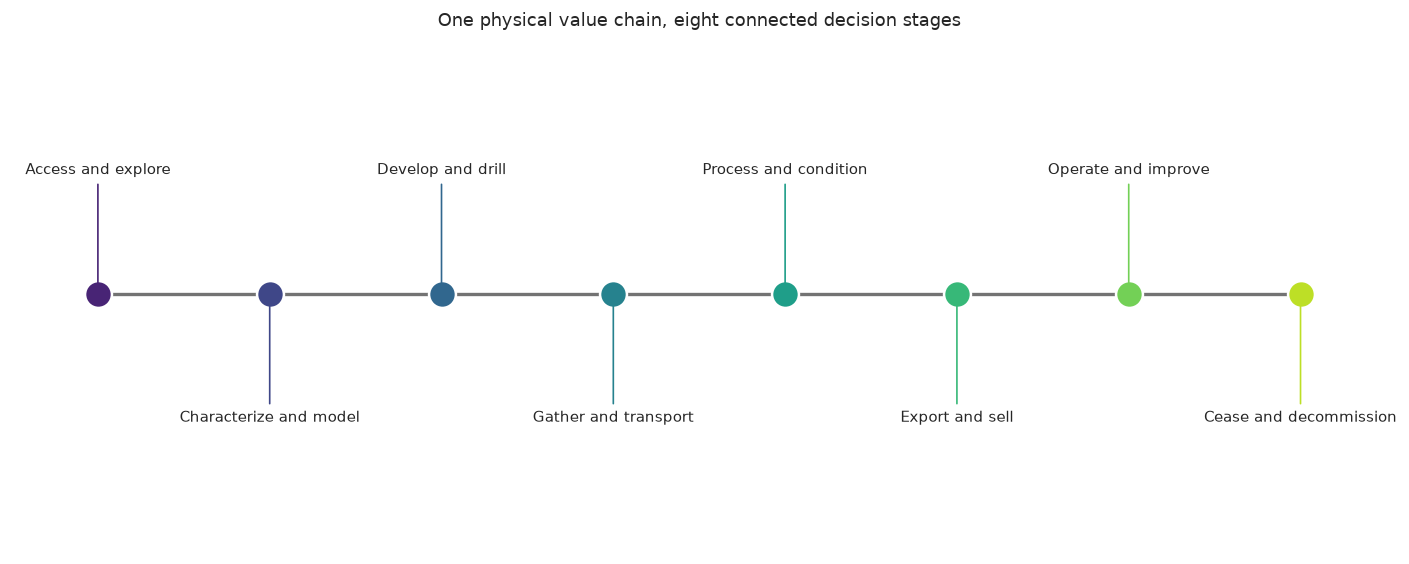

In [4]:
stages = pd.DataFrame(
    {
        "stage": [
            "Access and explore",
            "Characterize and model",
            "Develop and drill",
            "Gather and transport",
            "Process and condition",
            "Export and sell",
            "Operate and improve",
            "Cease and decommission",
        ],
        "main decision": [
            "Where and whether to explore",
            "Resource range and production forecast",
            "Concept, wells, capacity, and schedule",
            "Deliverability and flow-assurance envelope",
            "Saleable oil, gas, and managed water",
            "Quality, nominations, logistics, and value",
            "Availability, integrity, optimization, emissions",
            "Economic limit, safe isolation, and removal",
        ],
        "NeqSim role": [
            "Fluid sample screen",
            "Supporting property checks and flash translations",
            "Well/SURF/process design cases",
            "Multiphase hydraulics and flow assurance",
            "Separation, compression, treatment, utilities",
            "Product quality, export energy, terminal states",
            "Digital twin, consequence, energy, accounting",
            "Inventory, depressurization, flushing basis",
        ],
    }
)
display(stages)

fig, axis = plt.subplots(figsize=(12, 4.8))
x_positions = np.arange(len(stages))
y_positions = np.where(x_positions % 2 == 0, 0.62, 0.38)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(stages)))

axis.plot(x_positions, np.full(len(stages), 0.5), color="0.45", linewidth=2)
for index, row in stages.iterrows():
    axis.scatter(
        index,
        0.5,
        s=260,
        color=colors[index],
        edgecolor="white",
        linewidth=1.5,
        zorder=3,
    )
    axis.annotate(
        row["stage"],
        xy=(index, 0.5),
        xytext=(index, y_positions[index]),
        ha="center",
        va="center",
        fontsize=9,
        arrowprops={"arrowstyle": "-", "color": colors[index]},
    )

axis.set_xlim(-0.5, len(stages) - 0.5)
axis.set_ylim(0.25, 0.75)
axis.set_title("One physical value chain, eight connected decision stages")
axis.axis("off")
plt.tight_layout()
plt.show()


## 2. One fluid becomes the common process contract

A representative reservoir stream is separated into gas, stabilized-liquid precursor, and produced
water. The calculation is deliberately compact: it establishes the phase and energy handoff used by
well, SURF, topside, export, produced-water, energy, emissions, and economic studies.

Detailed design remains in the linked specialist notebooks later in this notebook.


,stream,mass flow kg/h,pressure bara,temperature °C,next owner
0,export gas,2.528e+04,125,132.7,gas export and market
1,oil-processing feed,1.195e+05,65,72,oil stabilization and export
2,produced water,"5,174",65,72,produced-water treatment


,metric,value,unit
0,Mass residual,4.075e-14,fraction
1,Export-compressor power,886.5,kW


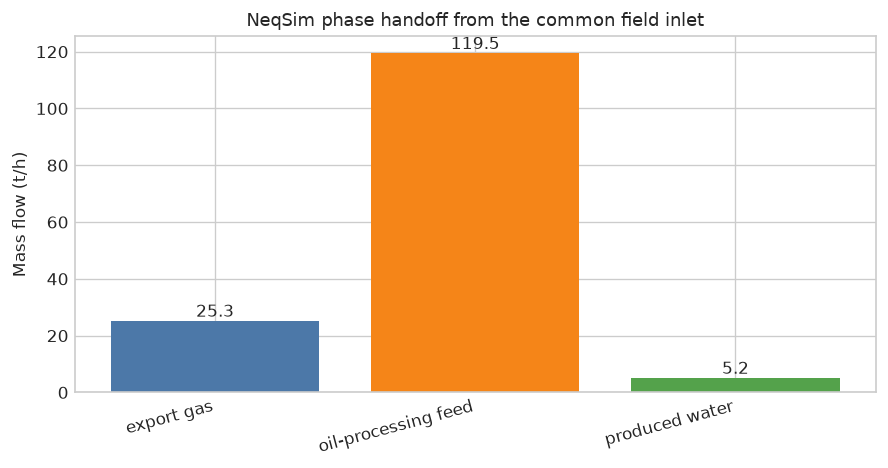

In [5]:
SystemSrkCPA = JClass("neqsim.thermo.system.SystemSrkCPAstatoil")
Stream = JClass("neqsim.process.equipment.stream.Stream")
ThreePhaseSeparator = JClass(
    "neqsim.process.equipment.separator.ThreePhaseSeparator"
)
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")

feed_fluid = SystemSrkCPA(273.15 + 72.0, 65.0)
feed_composition = {
    "methane": 48.0,
    "ethane": 6.0,
    "propane": 4.0,
    "n-heptane": 20.0,
    "nC10": 12.0,
    "water": 10.0,
}
for component, amount in feed_composition.items():
    feed_fluid.addComponent(component, amount)
feed_fluid.setMixingRule(10)
feed_fluid.setMultiPhaseCheck(True)

wellstream = Stream("Field inlet", feed_fluid)
wellstream.setFlowRate(150_000.0, "kg/hr")
wellstream.run()

separator = ThreePhaseSeparator("HP three-phase separator", wellstream)
separator.run()
gas_stream = separator.getGasOutStream()
oil_stream = separator.getOilOutStream()
water_stream = separator.getWaterOutStream()

export_compressor = Compressor("Export compressor", gas_stream)
export_compressor.setOutletPressure(125.0)
export_compressor.setIsentropicEfficiency(0.78)
export_compressor.run()

phase_rates = np.array(
    [
        gas_stream.getFlowRate("kg/hr"),
        oil_stream.getFlowRate("kg/hr"),
        water_stream.getFlowRate("kg/hr"),
    ]
)
mass_residual = abs(phase_rates.sum() - wellstream.getFlowRate("kg/hr"))
relative_mass_residual = mass_residual / wellstream.getFlowRate("kg/hr")
compressor_power_kw = float(export_compressor.getPower("kW"))

handoff = pd.DataFrame(
    {
        "stream": ["export gas", "oil-processing feed", "produced water"],
        "mass flow kg/h": phase_rates,
        "pressure bara": [
            export_compressor.getOutletStream().getPressure("bara"),
            oil_stream.getPressure("bara"),
            water_stream.getPressure("bara"),
        ],
        "temperature °C": [
            export_compressor.getOutletStream().getTemperature("C"),
            oil_stream.getTemperature("C"),
            water_stream.getTemperature("C"),
        ],
        "next owner": [
            "gas export and market",
            "oil stabilization and export",
            "produced-water treatment",
        ],
    }
)
assert relative_mass_residual < 1.0e-8
assert compressor_power_kw > 0.0
display(handoff.round(2))
display(
    pd.DataFrame(
        {
            "metric": ["Mass residual", "Export-compressor power"],
            "value": [relative_mass_residual, compressor_power_kw],
            "unit": ["fraction", "kW"],
        }
    )
)

fig, axis = plt.subplots(figsize=(7.5, 4.0))
bars = axis.bar(
    handoff["stream"],
    handoff["mass flow kg/h"] / 1_000.0,
    color=["#4c78a8", "#f58518", "#54a24b"],
)
axis.bar_label(bars, fmt="%.1f")
axis.set_ylabel("Mass flow (t/h)")
axis.set_title("NeqSim phase handoff from the common field inlet")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


## 3. Field life couples disciplines that are often studied separately

Declining hydrocarbon deliverability and increasing water fraction move the dominant constraint from
reservoir/wells to compression, liquid processing, water handling, availability, and finally the
economic limit. Capacity utilization for service $j$ is

$$

U_j(t)=\frac{L_j(t)}{C_j}

$$

where $L_j$ is the time-dependent load and $C_j$ is available capacity. The largest utilization is
the active bottleneck. This reduced field-life model uses NeqSim's baseline phase split and specific
compression demand; a mature study would re-run the complete compositional process for each
reservoir realization and operating state.


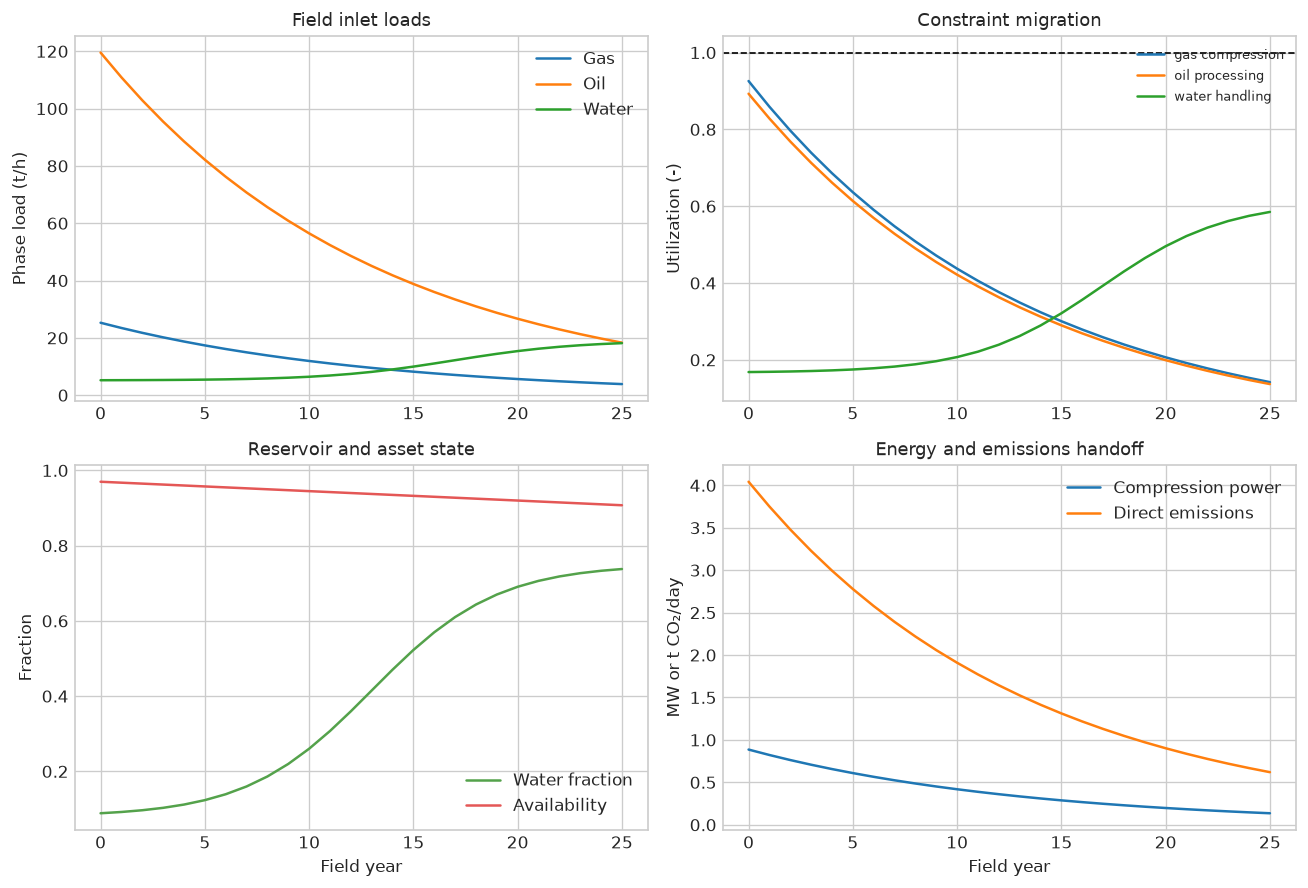

,year,gas t/h,oil t/h,water t/h,water fraction,availability,maximum utilization,active constraint,compression MW,direct emissions t/d
0,0,25.28,119.5,5.223,0.089,0.97,0.926,gas compression,0.886,4.042
5,5,17.38,82.16,5.431,0.124,0.958,0.636,gas compression,0.609,2.778
10,10,11.94,56.47,6.434,0.26,0.945,0.437,gas compression,0.419,1.909
15,15,8.207,38.81,9.973,0.523,0.932,0.321,water handling,0.288,1.312
20,20,5.641,26.67,15.39,0.691,0.92,0.496,water handling,0.198,0.902
25,25,3.877,18.33,18.16,0.738,0.908,0.585,water handling,0.136,0.62


In [6]:
field_year = np.arange(0, 26)
hydrocarbon_factor = np.exp(-0.075 * field_year)
water_fraction = 0.08 + 0.67 / (1.0 + np.exp(-(field_year - 13.0) / 3.0))
availability = np.clip(0.97 - 0.0025 * field_year, 0.88, 1.0)

base_gas_kg_h = phase_rates[0]
base_oil_kg_h = phase_rates[1]
base_water_kg_h = phase_rates[2]
gas_load = base_gas_kg_h * hydrocarbon_factor
oil_load = base_oil_kg_h * hydrocarbon_factor
water_load = base_water_kg_h * (1.0 - 0.08) / (1.0 - water_fraction)

capacities = {
    "gas compression": base_gas_kg_h * 1.08,
    "oil processing": base_oil_kg_h * 1.12,
    "water handling": base_water_kg_h * 6.0,
}
utilization = pd.DataFrame(
    {
        "gas compression": gas_load / capacities["gas compression"],
        "oil processing": oil_load / capacities["oil processing"],
        "water handling": water_load / capacities["water handling"],
    },
    index=field_year,
)
maximum_utilization = utilization.max(axis=1)
active_constraint = utilization.idxmax(axis=1)
compression_power_mw = compressor_power_kw * gas_load / base_gas_kg_h / 1_000.0
direct_emissions_t_d = compression_power_mw * 24.0 * 0.19

field_life = pd.DataFrame(
    {
        "year": field_year,
        "gas t/h": gas_load / 1_000.0,
        "oil t/h": oil_load / 1_000.0,
        "water t/h": water_load / 1_000.0,
        "water fraction": water_fraction,
        "availability": availability,
        "maximum utilization": maximum_utilization,
        "active constraint": active_constraint,
        "compression MW": compression_power_mw,
        "direct emissions t/d": direct_emissions_t_d,
    }
)

fig, axes = plt.subplots(2, 2, figsize=(11, 7.5))
axes[0, 0].plot(field_year, field_life["gas t/h"], label="Gas")
axes[0, 0].plot(field_year, field_life["oil t/h"], label="Oil")
axes[0, 0].plot(field_year, field_life["water t/h"], label="Water")
axes[0, 0].set(ylabel="Phase load (t/h)", title="Field inlet loads")
axes[0, 0].legend()

for column in utilization.columns:
    axes[0, 1].plot(field_year, utilization[column], label=column)
axes[0, 1].axhline(1.0, color="black", linestyle="--", linewidth=1)
axes[0, 1].set(ylabel="Utilization (-)", title="Constraint migration")
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(field_year, water_fraction, color="#54a24b", label="Water fraction")
axes[1, 0].plot(field_year, availability, color="#e45756", label="Availability")
axes[1, 0].set(xlabel="Field year", ylabel="Fraction", title="Reservoir and asset state")
axes[1, 0].legend()

axes[1, 1].plot(field_year, compression_power_mw, label="Compression power")
axes[1, 1].plot(field_year, direct_emissions_t_d, label="Direct emissions")
axes[1, 1].set(
    xlabel="Field year",
    ylabel="MW or t CO₂/day",
    title="Energy and emissions handoff",
)
axes[1, 1].legend()
plt.tight_layout()
plt.show()

display(field_life.iloc[::5].round(3))


## 4. Capability map: NeqSim supports governed discipline workflows

The map below uses three roles:

- **2 — primary engine:** NeqSim directly calculates the thermodynamic or process result.
- **1 — supporting service:** NeqSim supplies properties, boundaries, or consequence calculations.
- **0 — external handoff:** another governed tool is primary; NeqSim receives or returns a contract.

The PVT column is intentionally supporting everywhere. PVT laboratories and specialist
characterization/reservoir-model workflows own measured-data interpretation, EOS tuning,
uncertainty, and approved simulator tables. NeqSim receives that governed basis for independent
checks and downstream calculations. OPM Flow, ERT, GIS, structural, drilling, reliability, market,
scheduling, and cost tools likewise remain primary in their domains.

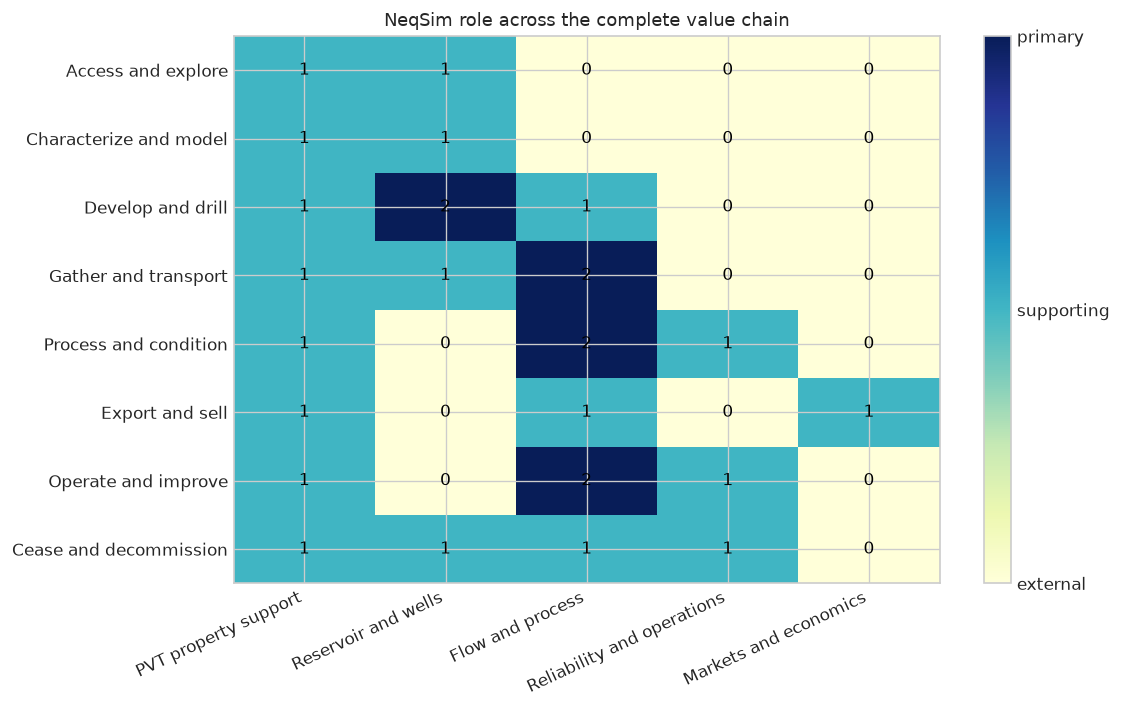

In [7]:
capabilities = [
    "PVT property support",
    "Reservoir and wells",
    "Flow and process",
    "Reliability and operations",
    "Markets and economics",
]
role_matrix = np.array(
    [
        [1, 1, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 2, 1, 0, 0],
        [1, 1, 2, 0, 0],
        [1, 0, 2, 1, 0],
        [1, 0, 1, 0, 1],
        [1, 0, 2, 1, 0],
        [1, 1, 1, 1, 0],
    ]
)

assert np.all(role_matrix[:, 0] == 1)

fig, axis = plt.subplots(figsize=(9.5, 6.0))
image = axis.imshow(role_matrix, cmap="YlGnBu", vmin=0, vmax=2, aspect="auto")
axis.set_xticks(np.arange(len(capabilities)), labels=capabilities)
axis.set_yticks(np.arange(len(stages)), labels=stages["stage"])
plt.setp(axis.get_xticklabels(), rotation=25, ha="right")
for row in range(role_matrix.shape[0]):
    for column in range(role_matrix.shape[1]):
        axis.text(
            column,
            row,
            str(role_matrix[row, column]),
            ha="center",
            va="center",
            color="black",
        )
axis.set_title("NeqSim role across the complete value chain")
colorbar = fig.colorbar(image, ax=axis, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["external", "supporting", "primary"])
plt.tight_layout()
plt.show()

## 5. Recommended learning path through the detailed notebooks

1. **Fluid basis:** [modern fluid properties](../thermodynamics/modern_fluid_property_workflow.ipynb)
   and [PVT workflow](../PVT/pvt_workflow_from_lab_to_simulator.ipynb).
2. **Subsurface:** [rock flow](../reservoir/rock_flow_pore_to_field_neqsim.ipynb),
   [OPM Flow coupling](../reservoir/neqsim_opm_flow_blackoil_coupling.ipynb), and
   [uncertainty with ERT](../reservoir/ert_neqsim_integrated_field_development.ipynb).
3. **Wells and gathering:** [integrated wells](../well/integrated_wells_drilling_completion_lift_injection_intervention.ipynb),
   [subsea systems](../subseaequipment/subseaequipment.ipynb), and
   [minimum-flow hydraulics](../fluidflow/minimum_flow_long_multiphase_flowline.ipynb).
4. **Facilities:** [integrated oil and gas process](../process/oil_and_gas_Process_with_ngl_stabilizer_and_tex_process.ipynb),
   [produced water and chemicals](../production/produced_water_sand_chemicals_management.ipynb), and
   [energy and emissions](../power/neqsim_ecalc_integrated_energy_emissions.ipynb).
5. **Export and value:** [gas sales](../gasvaluechain/european_gas_sales_market_foundation.ipynb),
   [oil sales](../gasvaluechain/european_crude_oil_sales_foundation.ipynb), and
   [stochastic reservoir-to-market optimization](../reservoir/stochastic_reservoir_to_market_optimization.ipynb).
6. **Operate and retire:** [asset management](../operations/operations_asset_management_with_neqsim.ipynb)
   and the companion commissioning-to-decommissioning notebook in this section.

These links form a dependency-ordered curriculum rather than a claim that every notebook must be
completed before the next one.


In [8]:
validation = pd.DataFrame(
    {
        "check": [
            "Public-PyPI package and JAR identity",
            "Three-phase mass closure",
            "Finite compressor demand",
            "Finite field-life results",
            "Every value-chain stage mapped",
            "PVT is supporting at every stage",
        ],
        "passed": [
            version("neqsim") == neqsim_jar.stem.removeprefix("neqsim-")
            and len(neqsim_jar_sha256) == 64,
            relative_mass_residual < 1.0e-8,
            np.isfinite(compressor_power_kw) and compressor_power_kw > 0.0,
            np.isfinite(field_life.select_dtypes("number").to_numpy()).all(),
            len(stages) == role_matrix.shape[0],
            np.all(role_matrix[:, 0] == 1),
        ],
    }
)
if not validation["passed"].all():
    raise AssertionError(validation.to_string(index=False))
display(validation)

print(
    f"Baseline split: gas {phase_rates[0] / 1_000:.1f} t/h, "
    f"oil {phase_rates[1] / 1_000:.1f} t/h, "
    f"water {phase_rates[2] / 1_000:.1f} t/h."
)
print(
    f"The active constraint changes from {active_constraint.iloc[0]} "
    f"to {active_constraint.iloc[-1]} over the illustrative field life."
)

Baseline split: gas 25.3 t/h, oil 119.5 t/h, water 5.2 t/h.
The active constraint changes from gas compression to water handling over the illustrative field life.


,check,passed
0,Public-PyPI package and JAR identity,True
1,Three-phase mass closure,True
2,Finite compressor demand,True
3,Finite field-life results,True
4,Every value-chain stage mapped,True
5,PVT is supporting at every stage,True


## Interpretation and limitations

The useful result is the architecture: the same governed fluid and operating cases must connect
subsurface, wells, facilities, operations, products, emissions, and value. NeqSim is strongest at
thermodynamic, flow, process, energy, and physical-consequence boundaries; it should be composed
with specialist tools instead of being stretched into unsupported domains.

The field-life curves use simplified decline, water-fraction, capacity, emissions, and availability
assumptions. They demonstrate coupling and constraint migration, not forecast accuracy. A project
study should preserve internally consistent reservoir/process/economic realizations, measured
equipment envelopes, product specifications, uncertainty, and governed fiscal assumptions.


## 6. Start with ownership and a governed interface contract

Integration works when each result has one accountable owner and a documented consumer. The table
separates **ownership** from **calculation support**. In particular, NeqSim does not become the PVT
authority merely because it can perform flashes, regression, or property calculations.

Each handoff should identify the fluid-version ID, basis and units, reference conditions,
uncertainty, validity envelope, approval state, and change history. A downstream calculation must
fail visibly when those fields are absent or incompatible.

In [9]:
ownership_contract = pd.DataFrame(
    {
        "decision object": [
            "Measured fluid samples",
            "Characterized and tuned PVT basis",
            "Reservoir forecast",
            "Well and SURF operating envelope",
            "Facility and export performance",
            "Product quality and nominations",
            "Economics and decision gates",
        ],
        "primary owner": [
            "PVT laboratory and data custodian",
            "PVT specialist and reservoir modeler",
            "Reservoir engineering",
            "Well, subsea, and flow-assurance teams",
            "Process and facilities engineering",
            "Commercial operations and laboratory",
            "Asset and investment decision owner",
        ],
        "NeqSim contribution": [
            "Independent property and consistency checks",
            "Supporting flash checks and format translation",
            "Compositional boundary and process-response checks",
            "Property, phase, hydraulics, and consequence support",
            "Primary thermodynamic and process calculations",
            "ISO 6976 property support and condition translation",
            "Physical scenario evidence for the economic model",
        ],
        "minimum governed handoff": [
            "sample ID, conditions, method, uncertainty",
            "fluid version, EOS, tuning data, validity range",
            "realization ID, rates, pressures, compositions",
            "geometry, boundary cases, integrity limits",
            "equipment cases, margins, convergence, balances",
            "reference states, specification, traceability",
            "scenario ID, assumptions, ranges, approval state",
        ],
    }
)

display(ownership_contract)
assert ownership_contract.loc[1, "primary owner"].startswith("PVT specialist")
assert "Supporting" in ownership_contract.loc[1, "NeqSim contribution"]

,decision object,primary owner,NeqSim contribution,minimum governed handoff
0,Measured fluid samples,PVT laboratory and data custodian,Independent property and consistency checks,"sample ID, conditions, method, uncertainty"
1,Characterized and tuned PVT basis,PVT specialist and reservoir modeler,Supporting flash checks and format translation,"fluid version, EOS, tuning data, validity range"
2,Reservoir forecast,Reservoir engineering,Compositional boundary and process-response ch...,"realization ID, rates, pressures, compositions"
3,Well and SURF operating envelope,"Well, subsea, and flow-assurance teams","Property, phase, hydraulics, and consequence s...","geometry, boundary cases, integrity limits"
4,Facility and export performance,Process and facilities engineering,Primary thermodynamic and process calculations,"equipment cases, margins, convergence, balances"
5,Product quality and nominations,Commercial operations and laboratory,ISO 6976 property support and condition transl...,"reference states, specification, traceability"
6,Economics and decision gates,Asset and investment decision owner,Physical scenario evidence for the economic model,"scenario ID, assumptions, ranges, approval state"


## 7. Reusable application: separation, compression, cooling, and gas quality

The next workflow is the practical backbone of the notebook. For each operating scenario it:

1. builds a fresh SRK-CPA fluid from a governed composition;
2. connects a `Stream`, `ThreePhaseSeparator`, `Compressor`, and `Cooler` in a `ProcessSystem`;
3. runs the connected process and checks unit status plus three-phase mass closure;
4. retrieves phase rates, power, cooling duty, and export-gas properties;
5. applies `Standard_ISO6976` for superior calorific value and Wobbe index.

The process balance is

$$

\dot{m}_{feed}-\sum_p\dot{m}_p=0

$$

where $p$ covers gas, oil, and aqueous separator outlets. Power and cooling duty are engineering
loads, while ISO 6976 values are commercial-quality handoffs at stated reference conditions.

,scenario,feed t/h,gas t/h,oil t/h,water t/h,compressor MW,cooling MW,gas MSm3/d,GCV MJ/Sm3,Wobbe MJ/Sm3,mass residual,process success
0,Reference,150,25.28,119.5,5.174,0.8865,2.137,0.7537,43.56,53.67,0,True
1,Turndown,90,15.17,71.73,3.104,0.5319,1.282,0.4522,43.56,53.67,0,True
2,High rate,180,30.34,143.5,6.209,1.064,2.564,0.9044,43.56,53.67,0,True
3,High water,150,24.23,114.6,11.16,0.8497,2.048,0.7224,43.56,53.67,0,True
4,CO2 rich,150,26.35,118.6,5.04,0.8258,2.053,0.708,40.8,47.71,0,True
5,Cold inlet,150,22.34,122.3,5.325,0.7448,1.321,0.6987,41.93,52.92,0,True


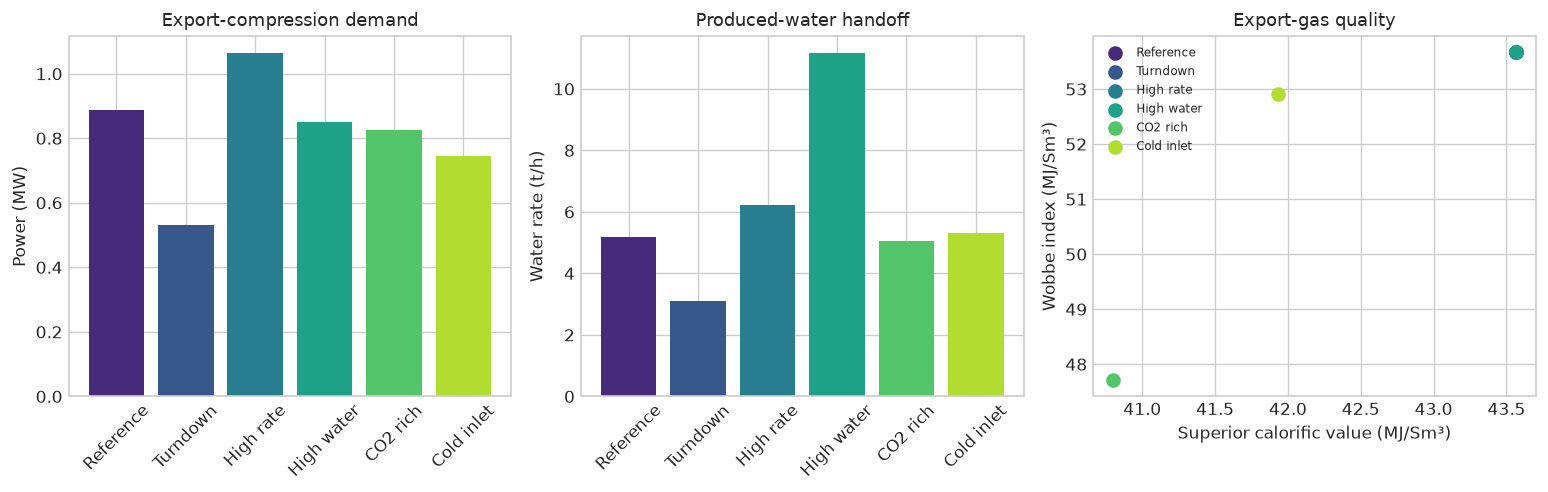

In [10]:
import json

Cooler = JClass("neqsim.process.equipment.heatexchanger.Cooler")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
StandardISO6976 = JClass("neqsim.standards.gasquality.Standard_ISO6976")

base_composition = {
    "methane": 48.0,
    "ethane": 6.0,
    "propane": 4.0,
    "n-heptane": 20.0,
    "nC10": 12.0,
    "water": 10.0,
}


def normalized_composition(composition):
    total = sum(composition.values())
    return {
        component: amount / total
        for component, amount in composition.items()
    }


def run_value_chain_case(name, flow_kg_h, temperature_c, pressure_bara, composition):
    fluid = SystemSrkCPA(temperature_c + 273.15, pressure_bara)
    for component, amount in composition.items():
        fluid.addComponent(component, amount)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)

    feed = Stream(f"{name} feed", fluid)
    feed.setFlowRate(flow_kg_h, "kg/hr")
    separator_unit = ThreePhaseSeparator(f"{name} separator", feed)
    compressor_unit = Compressor(
        f"{name} compressor",
        separator_unit.getGasOutStream(),
    )
    compressor_unit.setOutletPressure(125.0)
    compressor_unit.setIsentropicEfficiency(0.78)
    cooler_unit = Cooler(f"{name} export cooler", compressor_unit.getOutletStream())
    cooler_unit.setOutTemperature(273.15 + 35.0)

    process = ProcessSystem()
    for unit in [feed, separator_unit, compressor_unit, cooler_unit]:
        process.add(unit)
    process.run()

    run_status = json.loads(str(process.getRunStatusJson()))
    gas_out = separator_unit.getGasOutStream()
    oil_out = separator_unit.getOilOutStream()
    water_out = separator_unit.getWaterOutStream()
    phase_flow_kg_h = np.array(
        [
            gas_out.getFlowRate("kg/hr"),
            oil_out.getFlowRate("kg/hr"),
            water_out.getFlowRate("kg/hr"),
        ]
    )
    mass_residual_fraction = abs(phase_flow_kg_h.sum() - flow_kg_h) / flow_kg_h

    export_stream = cooler_unit.getOutletStream()
    export_fluid = export_stream.getThermoSystem()
    export_fluid.init(2)
    export_standard = StandardISO6976(export_fluid)
    export_standard.setReferenceType("volume")
    export_standard.setReferenceState("real")
    export_standard.setVolRefT(15.0)
    export_standard.setEnergyRefT(25.0)
    export_standard.calculate()

    return {
        "scenario": name,
        "feed t/h": flow_kg_h / 1_000.0,
        "gas t/h": phase_flow_kg_h[0] / 1_000.0,
        "oil t/h": phase_flow_kg_h[1] / 1_000.0,
        "water t/h": phase_flow_kg_h[2] / 1_000.0,
        "compressor MW": compressor_unit.getPower("kW") / 1_000.0,
        "cooling MW": abs(cooler_unit.getDuty()) / 1.0e6,
        "gas MSm3/d": export_stream.getFlowRate("Sm3/day") / 1.0e6,
        "GCV MJ/Sm3": export_standard.getValue("SuperiorCalorificValue") / 1_000.0,
        "Wobbe MJ/Sm3": export_standard.getValue("SuperiorWobbeIndex") / 1_000.0,
        "mass residual": mass_residual_fraction,
        "process success": bool(run_status["success"]),
    }


scenario_definitions = [
    ("Reference", 150_000.0, 72.0, 65.0, base_composition),
    ("Turndown", 90_000.0, 72.0, 65.0, base_composition),
    ("High rate", 180_000.0, 72.0, 65.0, base_composition),
    (
        "High water",
        150_000.0,
        72.0,
        65.0,
        {**base_composition, "water": 22.0},
    ),
    (
        "CO2 rich",
        150_000.0,
        72.0,
        65.0,
        {**base_composition, "CO2": 5.0, "methane": 43.0},
    ),
    ("Cold inlet", 150_000.0, 45.0, 65.0, base_composition),
]

scenario_results = pd.DataFrame(
    [
        run_value_chain_case(
            name,
            flow_kg_h,
            temperature_c,
            pressure_bara,
            composition,
        )
        for name, flow_kg_h, temperature_c, pressure_bara, composition
        in scenario_definitions
    ]
)

assert scenario_results["process success"].all()
assert scenario_results["mass residual"].max() < 1.0e-8
display(scenario_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13.0, 4.2))
scenario_colors = plt.cm.viridis(np.linspace(0.12, 0.88, len(scenario_results)))
axes[0].bar(
    scenario_results["scenario"],
    scenario_results["compressor MW"],
    color=scenario_colors,
)
axes[0].set(ylabel="Power (MW)", title="Export-compression demand")
axes[1].bar(
    scenario_results["scenario"],
    scenario_results["water t/h"],
    color=scenario_colors,
)
axes[1].set(ylabel="Water rate (t/h)", title="Produced-water handoff")
for (_, row), color in zip(scenario_results.iterrows(), scenario_colors):
    axes[2].scatter(
        row["GCV MJ/Sm3"],
        row["Wobbe MJ/Sm3"],
        color=color,
        s=60,
        label=row["scenario"],
    )
axes[2].set(
    xlabel="Superior calorific value (MJ/Sm³)",
    ylabel="Wobbe index (MJ/Sm³)",
    title="Export-gas quality",
)
axes[2].legend(fontsize=7, loc="best")
for axis in axes[:2]:
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

The high-rate case is the largest compression load, while the high-water case moves capacity into
the produced-water system. The CO₂-rich case shifts calorific value and Wobbe index even when the
equipment topology is unchanged. That is why a governed composition identifier must travel with
every scenario: a rate-only handoff is incomplete.

## 8. PVT support audit against synthetic laboratory observations

This section demonstrates the intended PVT boundary. The blue curve is a NeqSim SRK property
screen. The points are compact **synthetic laboratory observations** created for teaching; they are
not published experimental data. A PVT specialist would assess sample quality, select and tune the
fluid model, quantify uncertainty, and approve the reservoir-simulator representation. NeqSim is
used here to reproduce the governed basis and expose residuals for review.

The plotted residual is

$$

r_\rho=100\frac{\rho_{model}-\rho_{lab}}{\rho_{lab}}

$$

where density $\rho$ is in kg/m³. No parameter is tuned in this orientation example.

,pressure bara,synthetic lab density kg/m3,NeqSim density kg/m3,model residual %
0,20,16.65,16.46,-1.186
1,40,34.83,34.56,-0.794
2,60,54.14,54.36,0.402
3,80,75.94,75.71,-0.299
4,100,97.53,98.12,0.604
5,120,119.7,120.8,0.908


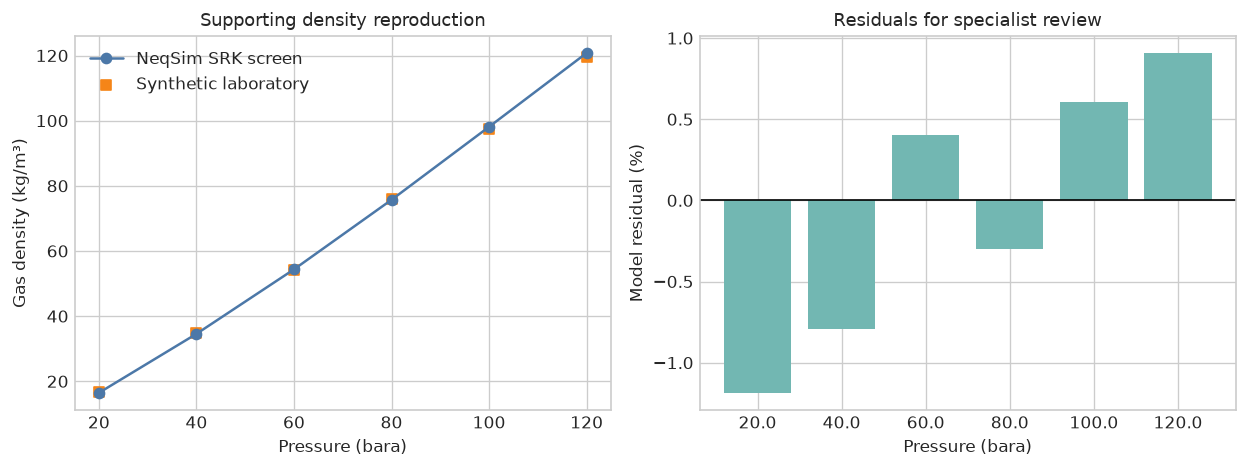

In [11]:
ThermodynamicOperations = JClass(
    "neqsim.thermodynamicoperations.ThermodynamicOperations"
)
SystemSrk = JClass("neqsim.thermo.system.SystemSrkEos")


def calculate_gas_density(pressure_bara, temperature_c=35.0):
    gas_fluid = SystemSrk(temperature_c + 273.15, pressure_bara)
    gas_composition = {
        "nitrogen": 0.01,
        "CO2": 0.03,
        "methane": 0.82,
        "ethane": 0.08,
        "propane": 0.04,
        "n-butane": 0.02,
    }
    for component, amount in gas_composition.items():
        gas_fluid.addComponent(component, amount)
    gas_fluid.setMixingRule(2)
    operations = ThermodynamicOperations(gas_fluid)
    operations.TPflash()
    gas_fluid.initPhysicalProperties()
    return gas_fluid.getPhase("gas").getDensity("kg/m3")


pvt_pressures_bara = np.array([20.0, 40.0, 60.0, 80.0, 100.0, 120.0])
model_density_kg_m3 = np.array(
    [calculate_gas_density(pressure) for pressure in pvt_pressures_bara]
)
synthetic_lab_offset = np.array([0.012, 0.008, -0.004, 0.003, -0.006, -0.009])
synthetic_lab_density_kg_m3 = model_density_kg_m3 * (1.0 + synthetic_lab_offset)
density_residual_percent = 100.0 * (
    model_density_kg_m3 - synthetic_lab_density_kg_m3
) / synthetic_lab_density_kg_m3

pvt_support_table = pd.DataFrame(
    {
        "pressure bara": pvt_pressures_bara,
        "synthetic lab density kg/m3": synthetic_lab_density_kg_m3,
        "NeqSim density kg/m3": model_density_kg_m3,
        "model residual %": density_residual_percent,
    }
)
display(pvt_support_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(
    pvt_pressures_bara,
    model_density_kg_m3,
    color="#4c78a8",
    marker="o",
    label="NeqSim SRK screen",
)
axes[0].scatter(
    pvt_pressures_bara,
    synthetic_lab_density_kg_m3,
    color="#f58518",
    marker="s",
    label="Synthetic laboratory",
)
axes[0].set(
    xlabel="Pressure (bara)",
    ylabel="Gas density (kg/m³)",
    title="Supporting density reproduction",
)
axes[0].legend()
axes[1].bar(
    pvt_pressures_bara.astype(str),
    density_residual_percent,
    color="#72b7b2",
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set(
    xlabel="Pressure (bara)",
    ylabel="Model residual (%)",
    title="Residuals for specialist review",
)
plt.tight_layout()
plt.show()

assert np.all(np.diff(model_density_kg_m3) > 0.0)
assert np.max(np.abs(density_residual_percent)) < 2.0

The monotonic density trend is physically plausible and the synthetic residuals stay within 2%.
That is a QA observation, not an EOS-approval criterion. Real acceptance limits depend on the
measurement method, fluid class, depletion path, intended decision, and uncertainty agreed by the
PVT and reservoir teams.

## 9. SURF screening from the governed process state

A preliminary single-phase gas screen translates NeqSim density and viscosity into velocity,
Reynolds number, Darcy friction factor, and pressure gradient. For pipe length $L$, diameter $D$,
density $\rho$, and velocity $v$,

$$

\Delta p=f\frac{L}{D}\frac{\rho v^2}{2}

$$

This is useful for consistency checks and early option comparison. It does **not** replace a
multiphase flow-assurance model, terrain profile, heat-transfer model, transient analysis, slugging
study, erosion assessment, or detailed pipeline design.

,mass flow kg/s,velocity m/s,Reynolds number,Darcy friction factor,pressure drop bar
0,4,0.1716,6.113e+05,0.0139,0.0292
1,6.5,0.2788,9.934e+05,0.0132,0.0734
2,9,0.3861,1.376e+06,0.0129,0.137
3,11.5,0.4933,1.758e+06,0.0127,0.2197
4,14,0.6006,2.14e+06,0.0125,0.3216
5,16.5,0.7078,2.522e+06,0.0124,0.4425
6,19,0.8151,2.904e+06,0.0123,0.5825
7,21.5,0.9223,3.286e+06,0.0122,0.7416
8,24,1.03,3.668e+06,0.0122,0.9197


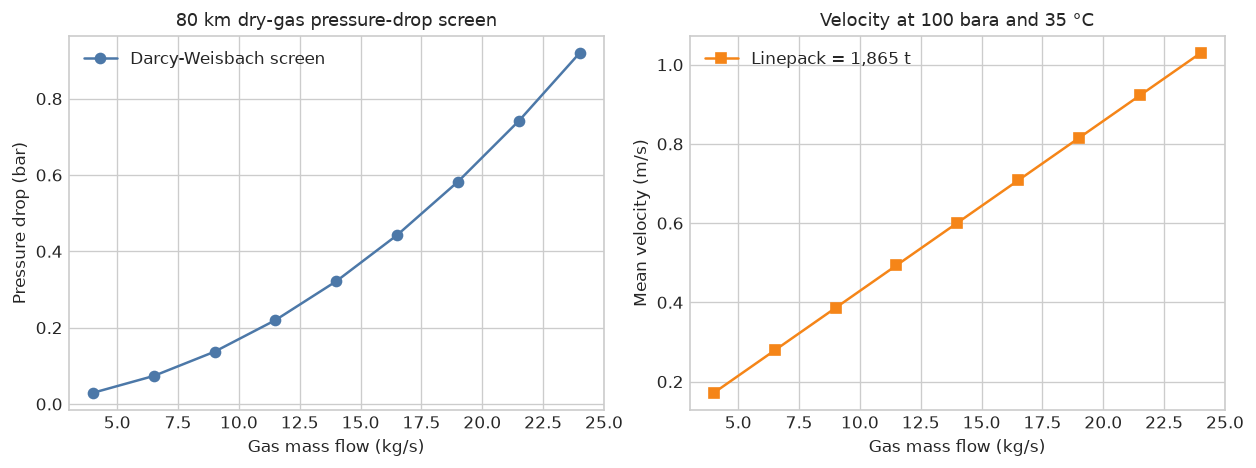

In [12]:
screen_temperature_c = 35.0
screen_pressure_bara = 100.0
screen_fluid = SystemSrk(screen_temperature_c + 273.15, screen_pressure_bara)
for component, amount in {
    "nitrogen": 0.01,
    "CO2": 0.03,
    "methane": 0.82,
    "ethane": 0.08,
    "propane": 0.04,
    "n-butane": 0.02,
}.items():
    screen_fluid.addComponent(component, amount)
screen_fluid.setMixingRule(2)
ThermodynamicOperations(screen_fluid).TPflash()
screen_fluid.initPhysicalProperties()
screen_phase = screen_fluid.getPhase("gas")
screen_density_kg_m3 = screen_phase.getDensity("kg/m3")
screen_viscosity_pa_s = screen_phase.getViscosity("kg/msec")

pipe_length_m = 80_000.0
pipe_diameter_m = 0.55
pipe_roughness_m = 4.5e-5
pipe_area_m2 = np.pi * pipe_diameter_m**2 / 4.0
screen_mass_flow_kg_s = np.linspace(4.0, 24.0, 9)
screen_velocity_m_s = screen_mass_flow_kg_s / (screen_density_kg_m3 * pipe_area_m2)
screen_reynolds = (
    screen_density_kg_m3
    * screen_velocity_m_s
    * pipe_diameter_m
    / screen_viscosity_pa_s
)
relative_roughness = pipe_roughness_m / pipe_diameter_m
screen_friction_factor = 0.25 / (
    np.log10(relative_roughness / 3.7 + 5.74 / screen_reynolds**0.9) ** 2
)
screen_pressure_drop_bar = (
    screen_friction_factor
    * pipe_length_m
    / pipe_diameter_m
    * screen_density_kg_m3
    * screen_velocity_m_s**2
    / 2.0
    / 1.0e5
)
screen_linepack_tonnes = (
    screen_density_kg_m3 * pipe_area_m2 * pipe_length_m / 1_000.0
)

hydraulic_screen = pd.DataFrame(
    {
        "mass flow kg/s": screen_mass_flow_kg_s,
        "velocity m/s": screen_velocity_m_s,
        "Reynolds number": screen_reynolds,
        "Darcy friction factor": screen_friction_factor,
        "pressure drop bar": screen_pressure_drop_bar,
    }
)
display(hydraulic_screen.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(
    screen_mass_flow_kg_s,
    screen_pressure_drop_bar,
    color="#4c78a8",
    marker="o",
    label="Darcy-Weisbach screen",
)
axes[0].set(
    xlabel="Gas mass flow (kg/s)",
    ylabel="Pressure drop (bar)",
    title="80 km dry-gas pressure-drop screen",
)
axes[0].legend()
axes[1].plot(
    screen_mass_flow_kg_s,
    screen_velocity_m_s,
    color="#f58518",
    marker="s",
    label=f"Linepack = {screen_linepack_tonnes:,.0f} t",
)
axes[1].set(
    xlabel="Gas mass flow (kg/s)",
    ylabel="Mean velocity (m/s)",
    title="Velocity at 100 bara and 35 °C",
)
axes[1].legend()
plt.tight_layout()
plt.show()

assert np.all(np.diff(screen_pressure_drop_bar) > 0.0)
assert np.all(screen_reynolds > 4_000.0)

Pressure loss rises faster than flow because velocity and dynamic pressure increase together. The
screen also reports the thermodynamic state behind its density, viscosity, and linepack. A project
handoff would add the elevation profile, wall and insulation data, fluid uncertainty, operating
envelope, and explicit criteria for escalation to steady or transient multiphase analysis.

## 10. Gas quality and the commercial handoff

ISO 6976 calculations connect composition to superior calorific value and Wobbe index. The
calorific-value handoff converts standard volume to energy:

$$

E=V_n H_s

$$

where $V_n$ is standard volume in Sm³ and $H_s$ is superior calorific value in MJ/Sm³. Reference
conditions and whether the state is real or ideal are part of the contractual definition, not
plotting details.

,CO2 mol%,GCV MJ/Sm3,Wobbe MJ/Sm3,relative density,energy TJ/d
0,0,43.62,53.43,0.6662,32.87
1,1,43.24,52.59,0.6759,32.59
2,2,42.86,51.76,0.6857,32.3
3,3,42.49,50.95,0.6954,32.02
4,4,42.11,50.15,0.7051,31.74
5,5,41.73,49.36,0.7148,31.45
6,6,41.36,48.59,0.7245,31.17
7,7,40.98,47.83,0.7342,30.89
8,8,40.6,47.08,0.7439,30.6


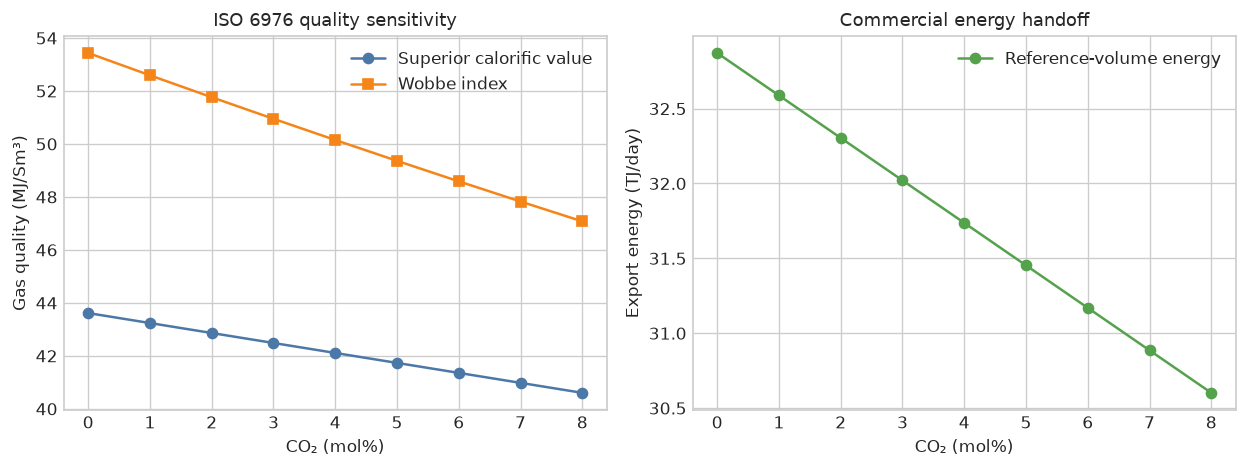

In [13]:
def calculate_iso6976_quality(co2_fraction):
    quality_fluid = SystemSrk(273.15 + 15.0, 1.01325)
    quality_composition = {
        "nitrogen": 0.01,
        "CO2": co2_fraction,
        "methane": 0.85 - co2_fraction,
        "ethane": 0.08,
        "propane": 0.04,
        "n-butane": 0.02,
    }
    for component, amount in quality_composition.items():
        quality_fluid.addComponent(component, amount)
    quality_fluid.setMixingRule(2)
    ThermodynamicOperations(quality_fluid).TPflash()
    quality_fluid.init(2)
    standard = StandardISO6976(quality_fluid)
    standard.setReferenceType("volume")
    standard.setReferenceState("real")
    standard.setVolRefT(15.0)
    standard.setEnergyRefT(25.0)
    standard.calculate()
    return {
        "CO2 mol%": 100.0 * co2_fraction,
        "GCV MJ/Sm3": standard.getValue("SuperiorCalorificValue") / 1_000.0,
        "Wobbe MJ/Sm3": standard.getValue("SuperiorWobbeIndex") / 1_000.0,
        "relative density": standard.getValue("RelativeDensity"),
    }


co2_fractions = np.linspace(0.0, 0.08, 9)
gas_quality = pd.DataFrame(
    [calculate_iso6976_quality(fraction) for fraction in co2_fractions]
)
reference_gas_volume_sm3_d = scenario_results.loc[
    scenario_results["scenario"] == "Reference",
    "gas MSm3/d",
].iloc[0] * 1.0e6
gas_quality["energy TJ/d"] = (
    reference_gas_volume_sm3_d * gas_quality["GCV MJ/Sm3"] / 1.0e6
)
display(gas_quality.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot(
    gas_quality["CO2 mol%"],
    gas_quality["GCV MJ/Sm3"],
    color="#4c78a8",
    marker="o",
    label="Superior calorific value",
)
axes[0].plot(
    gas_quality["CO2 mol%"],
    gas_quality["Wobbe MJ/Sm3"],
    color="#f58518",
    marker="s",
    label="Wobbe index",
)
axes[0].set(
    xlabel="CO₂ (mol%)",
    ylabel="Gas quality (MJ/Sm³)",
    title="ISO 6976 quality sensitivity",
)
axes[0].legend()
axes[1].plot(
    gas_quality["CO2 mol%"],
    gas_quality["energy TJ/d"],
    color="#54a24b",
    marker="o",
    label="Reference-volume energy",
)
axes[1].set(
    xlabel="CO₂ (mol%)",
    ylabel="Export energy (TJ/day)",
    title="Commercial energy handoff",
)
axes[1].legend()
plt.tight_layout()
plt.show()

assert np.all(np.diff(gas_quality["GCV MJ/Sm3"]) < 0.0)
assert np.all(np.diff(gas_quality["energy TJ/d"]) < 0.0)

Increasing CO₂ lowers both energy per standard cubic metre and the nominated daily energy at fixed
volume. A commercial workflow must use custody-transfer composition and approved reference
conditions. The process model supplies a decision-consistent forecast; it does not replace the
metering system or contractual allocation process.

## 11. Carry physical uncertainty into value

The process result anchors a compact probabilistic value screen. Each realization samples initial
gas rate, decline, uptime, gas price, operating cost, discount rate, and CO₂ price. Discounted net
present value is

$$

NPV=-CAPEX+\sum_{t=1}^{N}\frac{R_t-OPEX_t-C_t}{(1+r)^t}

$$

where revenue $R_t$, operating cost $OPEX_t$, carbon cost $C_t$, and discount rate $r$ are defined
for the same realization. The distributions are illustrative and must be replaced by governed
subsurface, facility, fiscal, and market uncertainty for an investment decision.

,metric,value BNOK
0,P10 NPV,-2.783
1,P50 NPV,-1.797
2,P90 NPV,-0.516


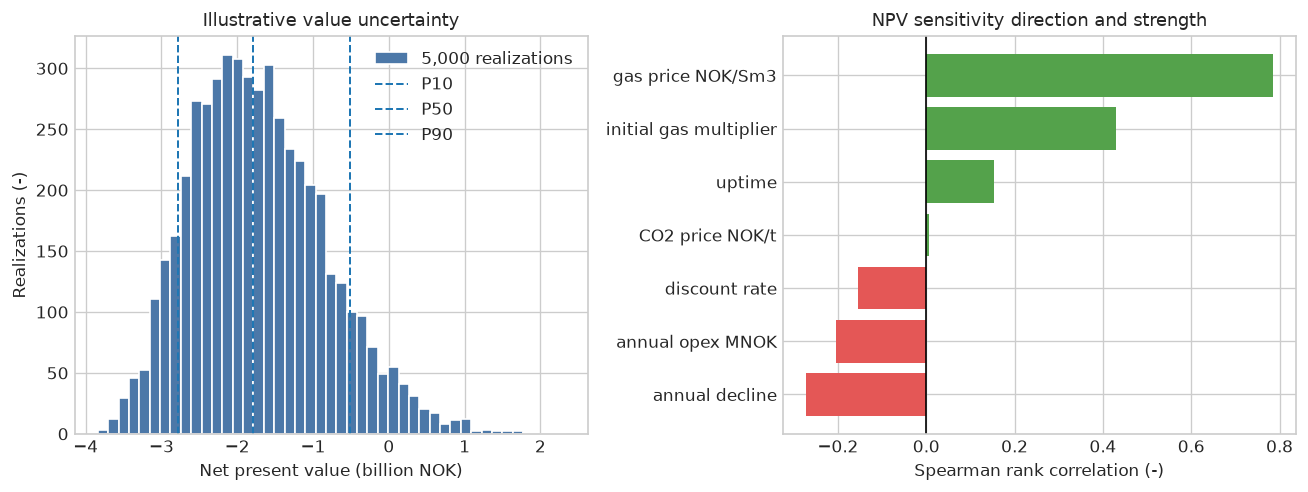

In [14]:
rng = np.random.default_rng(20260806)
sample_count = 5_000
project_years = np.arange(1, 21)

uncertainty_inputs = pd.DataFrame(
    {
        "initial gas multiplier": rng.triangular(0.75, 1.0, 1.25, sample_count),
        "annual decline": rng.triangular(0.035, 0.065, 0.10, sample_count),
        "uptime": rng.triangular(0.84, 0.93, 0.98, sample_count),
        "gas price NOK/Sm3": rng.triangular(1.4, 2.3, 3.5, sample_count),
        "annual opex MNOK": rng.triangular(90.0, 130.0, 190.0, sample_count),
        "discount rate": rng.triangular(0.06, 0.08, 0.12, sample_count),
        "CO2 price NOK/t": rng.triangular(700.0, 1_200.0, 2_000.0, sample_count),
    }
)

reference_annual_volume_sm3 = reference_gas_volume_sm3_d * 365.0
reference_emissions_t_y = direct_emissions_t_d[0] * 365.0
capital_cost_nok = 4.2e9
npv_nok = np.full(sample_count, -capital_cost_nok)

for year in project_years:
    annual_volume_sm3 = (
        reference_annual_volume_sm3
        * uncertainty_inputs["initial gas multiplier"]
        * (1.0 - uncertainty_inputs["annual decline"]) ** (year - 1)
        * uncertainty_inputs["uptime"]
    )
    annual_revenue_nok = annual_volume_sm3 * uncertainty_inputs["gas price NOK/Sm3"]
    annual_opex_nok = uncertainty_inputs["annual opex MNOK"] * 1.0e6
    annual_carbon_cost_nok = (
        reference_emissions_t_y
        * uncertainty_inputs["initial gas multiplier"]
        * uncertainty_inputs["CO2 price NOK/t"]
    )
    discount_factor = (1.0 + uncertainty_inputs["discount rate"]) ** year
    npv_nok += (
        annual_revenue_nok - annual_opex_nok - annual_carbon_cost_nok
    ) / discount_factor

uncertainty_inputs["NPV BNOK"] = npv_nok / 1.0e9
npv_percentiles = np.percentile(uncertainty_inputs["NPV BNOK"], [10, 50, 90])

sensitivity_rows = []
for column in uncertainty_inputs.columns[:-1]:
    correlation = stats.spearmanr(
        uncertainty_inputs[column],
        uncertainty_inputs["NPV BNOK"],
    ).statistic
    sensitivity_rows.append(
        {
            "input": column,
            "Spearman correlation": correlation,
        }
    )
sensitivity = pd.DataFrame(sensitivity_rows).sort_values("Spearman correlation")

display(
    pd.DataFrame(
        {
            "metric": ["P10 NPV", "P50 NPV", "P90 NPV"],
            "value BNOK": npv_percentiles,
        }
    ).round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
axes[0].hist(
    uncertainty_inputs["NPV BNOK"],
    bins=45,
    color="#4c78a8",
    edgecolor="white",
    label=f"{sample_count:,} realizations",
)
for percentile, label in zip(npv_percentiles, ["P10", "P50", "P90"]):
    axes[0].axvline(percentile, linestyle="--", linewidth=1.2, label=label)
axes[0].set(
    xlabel="Net present value (billion NOK)",
    ylabel="Realizations (-)",
    title="Illustrative value uncertainty",
)
axes[0].legend()
bar_colors = np.where(
    sensitivity["Spearman correlation"] >= 0.0,
    "#54a24b",
    "#e45756",
)
axes[1].barh(
    sensitivity["input"],
    sensitivity["Spearman correlation"],
    color=bar_colors,
)
axes[1].axvline(0.0, color="black", linewidth=1)
axes[1].set(
    xlabel="Spearman rank correlation (-)",
    title="NPV sensitivity direction and strength",
)
plt.tight_layout()
plt.show()

assert np.isfinite(uncertainty_inputs.to_numpy()).all()
assert npv_percentiles[0] < npv_percentiles[1] < npv_percentiles[2]

The percentile range is wider than a single deterministic answer and the rank correlations reveal
which assumptions dominate this teaching case. Correlation is not causation and does not allocate
risk ownership. A decision model should retain realization IDs so physical, availability, price,
fiscal, emissions, and cost assumptions can be traced back to their approved sources.

## 12. Convert calculations into explicit decision gates

The final application combines process convergence, balance closure, capacity, and gas-quality
checks. The limits are illustrative screening thresholds. A real project must source each limit
from design requirements, operating envelopes, product contracts, integrity management, and
regulatory obligations.

,scenario,gates passed,all gates passed,mass residual
0,Reference,6,True,4.094e-14
1,Turndown,6,True,4.107e-14
2,High rate,6,True,4.107e-14
3,High water,6,True,6.034e-14
4,CO2 rich,5,False,5.161e-14
5,Cold inlet,6,True,1.164e-14


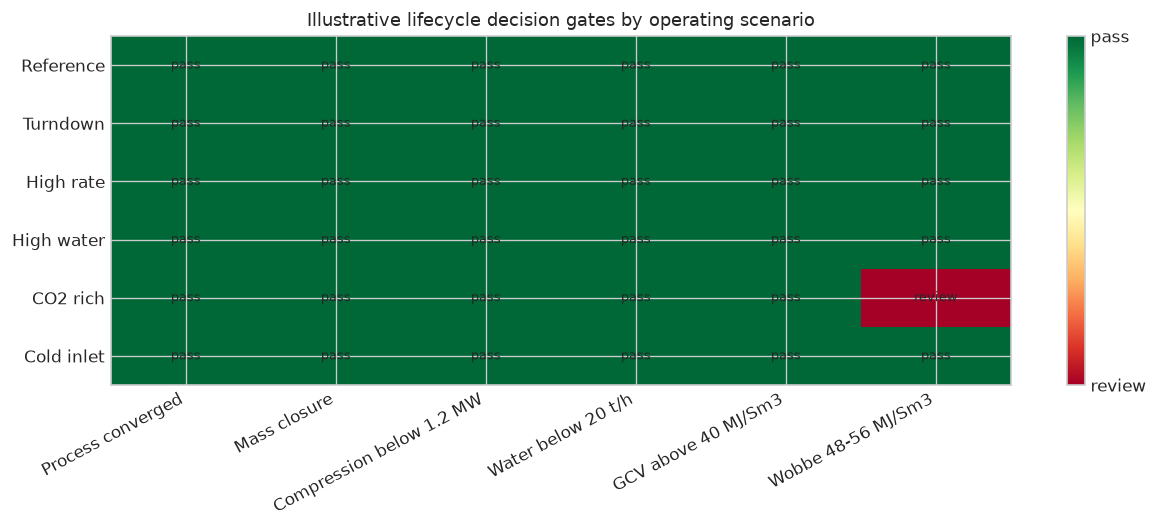

In [15]:
decision_gate_matrix = pd.DataFrame(
    {
        "Process converged": scenario_results["process success"].to_numpy(),
        "Mass closure": (scenario_results["mass residual"] < 1.0e-8).to_numpy(),
        "Compression below 1.2 MW": (
            scenario_results["compressor MW"] < 1.2
        ).to_numpy(),
        "Water below 20 t/h": (scenario_results["water t/h"] < 20.0).to_numpy(),
        "GCV above 40 MJ/Sm3": (
            scenario_results["GCV MJ/Sm3"] > 40.0
        ).to_numpy(),
        "Wobbe 48-56 MJ/Sm3": scenario_results["Wobbe MJ/Sm3"].between(
            48.0,
            56.0,
        ).to_numpy(),
    },
    index=scenario_results["scenario"],
)
scenario_results["gates passed"] = decision_gate_matrix.sum(axis=1).to_numpy()
scenario_results["all gates passed"] = decision_gate_matrix.all(axis=1).to_numpy()

display(
    scenario_results[
        [
            "scenario",
            "gates passed",
            "all gates passed",
            "mass residual",
        ]
    ]
)

fig, axis = plt.subplots(figsize=(10.5, 4.5))
gate_image = axis.imshow(
    decision_gate_matrix.astype(int),
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    aspect="auto",
)
axis.set_xticks(
    np.arange(decision_gate_matrix.shape[1]),
    labels=decision_gate_matrix.columns,
)
axis.set_yticks(
    np.arange(decision_gate_matrix.shape[0]),
    labels=decision_gate_matrix.index,
)
plt.setp(axis.get_xticklabels(), rotation=28, ha="right")
for row in range(decision_gate_matrix.shape[0]):
    for column in range(decision_gate_matrix.shape[1]):
        label = "pass" if decision_gate_matrix.iloc[row, column] else "review"
        axis.text(column, row, label, ha="center", va="center", fontsize=8)
axis.set_title("Illustrative lifecycle decision gates by operating scenario")
colorbar = fig.colorbar(gate_image, ax=axis, ticks=[0, 1])
colorbar.ax.set_yticklabels(["review", "pass"])
plt.tight_layout()
plt.show()

assert decision_gate_matrix["Process converged"].all()
assert decision_gate_matrix["Mass closure"].all()
assert (~decision_gate_matrix).any(axis=None)
assert scenario_results[["gates passed", "all gates passed"]].notna().all().all()

The matrix makes trade-offs visible: numerically valid scenarios can still require engineering or
commercial review. A failed screen is not automatically an infeasible design, and a passing screen
is not approval. The next owner must assess the underlying evidence and either accept the case,
request refinement, or reject it with a documented reason.

### Applicability and limitations

- The compositional process is a steady, compact teaching model without equipment sizing,
  controllers, recycle, relief, or detailed treatment.
- The density comparison uses synthetic observations and performs no PVT regression.
- The dry-gas hydraulic screen omits elevation, heat transfer, phase appearance, terrain slugging,
  and transient boundary changes.
- ISO 6976 values are calculated at stated reference conditions but are not custody-transfer data.
- Field-life and economic distributions are illustrative and exclude fiscal detail, liquids value,
  abandonment tax effects, correlations, schedule, and decision flexibility.
- Scenario limits are pedagogical; governed project criteria must replace them.

In [16]:
final_validation = pd.DataFrame(
    {
        "check": [
            "All original examples retained",
            "All six connected process scenarios converged",
            "Scenario mass closure",
            "PVT role remains supporting",
            "Synthetic density residual finite",
            "Gas density rises with pressure",
            "Hydraulic pressure drop rises with flow",
            "Hydraulic screen remains turbulent",
            "ISO 6976 quality values finite",
            "GCV falls as CO2 increases",
            "Economic realizations finite",
            "NPV percentiles ordered",
            "Decision gates include review cases",
            "Decision summary has no missing values",
            "Public-PyPI JAR provenance retained",
        ],
        "passed": [
            len(stages) == 8 and len(phase_rates) == 3 and len(field_life) == 26,
            scenario_results["process success"].all(),
            scenario_results["mass residual"].max() < 1.0e-8,
            np.all(role_matrix[:, 0] == 1),
            np.isfinite(density_residual_percent).all(),
            np.all(np.diff(model_density_kg_m3) > 0.0),
            np.all(np.diff(screen_pressure_drop_bar) > 0.0),
            np.all(screen_reynolds > 4_000.0),
            np.isfinite(gas_quality.select_dtypes("number").to_numpy()).all(),
            np.all(np.diff(gas_quality["GCV MJ/Sm3"]) < 0.0),
            np.isfinite(uncertainty_inputs.to_numpy()).all(),
            npv_percentiles[0] < npv_percentiles[1] < npv_percentiles[2],
            (~decision_gate_matrix).any(axis=None),
            scenario_results[
                ["gates passed", "all gates passed"]
            ].notna().all().all(),
            version("neqsim") == neqsim_jar.stem.removeprefix("neqsim-"),
        ],
    }
)
if not final_validation["passed"].all():
    raise AssertionError(final_validation.to_string(index=False))

display(final_validation)
print(
    f"Validated {len(scenario_results)} process scenarios, "
    f"{len(pvt_pressures_bara)} PVT-support points, "
    f"{len(screen_mass_flow_kg_s)} hydraulic points, and "
    f"{sample_count:,} economic realizations."
)
print(
    f"Maximum process mass residual: "
    f"{scenario_results['mass residual'].max():.3e}."
)

Validated 6 process scenarios, 6 PVT-support points, 9 hydraulic points, and 5,000 economic realizations.
Maximum process mass residual: 6.034e-14.


,check,passed
0,All original examples retained,True
1,All six connected process scenarios converged,True
2,Scenario mass closure,True
3,PVT role remains supporting,True
4,Synthetic density residual finite,True
5,Gas density rises with pressure,True
6,Hydraulic pressure drop rises with flow,True
7,Hydraulic screen remains turbulent,True
8,ISO 6976 quality values finite,True
9,GCV falls as CO2 increases,True


## Practical next steps and references

Try these extensions while preserving the ownership boundary:

1. Replace the synthetic density points with an approved public dataset, carry measurement
   uncertainty, and document the PVT specialist's acceptance criteria.
2. Pass multiple governed reservoir realizations through the reusable process function and retain
   realization IDs through the economic output.
3. Replace the dry-gas pressure-drop screen with a supported NeqSim pipeline model and compare
   steady and transient boundaries.
4. Add equipment capacity curves, availability states, export specifications, and traceable reasons
   for every rejected scenario.
5. Add liquids value, fiscal terms, decommissioning cash flow, and emissions uncertainty without
   breaking the link to the physical scenario.

Current official references used by this notebook:

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [Thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models)
- [PVT and fluid characterization](https://equinor.github.io/neqsim/thermo/pvt_fluid_characterization)
- [PVT simulation package](https://equinor.github.io/neqsim/pvtsimulation/)
- [Process simulation recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [Process design guide](https://equinor.github.io/neqsim/process/process_design_guide)

The PVT references describe available functionality. They do not change this notebook's governance
rule: NeqSim supports the approved PVT basis; laboratory, characterization, and reservoir-model
specialists remain accountable for that basis.